# Alpamayo-R1 Demo

This notebook will load some example data from the NVIDIA [PhysicalAI-AV Dataset](https://huggingface.co/datasets/nvidia/PhysicalAI-Autonomous-Vehicles) and run the Alpamayo-R1 model on it, producing and visualizing output trajectories and associated reasoning traces.

In [ ]:
import copy
import numpy as np
import mediapy as mp
import pandas as pd
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"
os.environ["HF_ENDPOINT"] = "https://hf-mirror.com"
from huggingface_hub import whoami
try:
    user_info = whoami()
    print("✅ 登录成功！")
    print(f"用户名: {user_info.get('name', 'N/A')}")
    print(f"用户ID: {user_info.get('id', 'N/A')}")
    print(f"Token类型: {user_info.get('type', 'N/A')}")
    print(f"完整信息: {user_info}")
except Exception as e:
    print(f"❌ 未登录或登录失败: {e}")
import torch
from alpamayo_r1.models.alpamayo_r1 import AlpamayoR1
from alpamayo_r1.load_physical_aiavdataset import load_physical_aiavdataset
from alpamayo_r1 import helper

✅ 登录成功！
用户名: liyiqiang0827
用户ID: 6786aeae4d0a7cd1bcffed63
Token类型: user
完整信息: {'type': 'user', 'id': '6786aeae4d0a7cd1bcffed63', 'name': 'liyiqiang0827', 'fullname': 'liyiqiang', 'canPay': False, 'billingMode': 'prepaid', 'periodEnd': 1772323200, 'isPro': False, 'avatarUrl': '/avatars/48339b25b812f14b375033d82f4ac326.svg', 'orgs': [], 'auth': {'type': 'access_token', 'accessToken': {'displayName': 'alpamayo_test', 'role': 'fineGrained', 'createdAt': '2026-01-22T10:52:11.277Z', 'fineGrained': {'canReadGatedRepos': True, 'global': ['discussion.write', 'post.write'], 'scoped': [{'entity': {'_id': '6786aeae4d0a7cd1bcffed63', 'type': 'user', 'name': 'liyiqiang0827'}, 'permissions': ['repo.content.read', 'repo.write', 'inference.serverless.write', 'inference.endpoints.infer.write', 'inference.endpoints.write', 'user.webhooks.read', 'user.webhooks.write', 'collection.read', 'collection.write', 'discussion.write', 'user.billing.read', 'job.write']}]}}}}


### Load model and construct data preprocessor

In [2]:
model = AlpamayoR1.from_pretrained("nvidia/Alpamayo-R1-10B", dtype=torch.bfloat16).to("cuda")
processor = helper.get_processor(model.tokenizer)

Loading checkpoint shards:   0%|          | 0/5 [00:00<?, ?it/s]

### Load and prepare data

In [3]:
clip_ids = pd.read_parquet("clip_ids.parquet")["clip_id"].tolist()
clip_id = clip_ids[30]
# clip_id = '030c760c-ae38-49aa-9ad8-f5650a545d26'

data = load_physical_aiavdataset(clip_id)

messages = helper.create_message(data["image_frames"].flatten(0, 1))

inputs = processor.apply_chat_template(
    messages,
    tokenize=True,
    add_generation_prompt=False,
    continue_final_message=True,
    return_dict=True,
    return_tensors="pt",
)
print("seq length:", inputs.input_ids.shape)
model_inputs = {
    "tokenized_data": inputs,
    "ego_history_xyz": data["ego_history_xyz"],
    "ego_history_rot": data["ego_history_rot"],
}
model_inputs = helper.to_device(model_inputs, "cuda")

KeyboardInterrupt: 

### Model inference

In [ ]:
torch.cuda.manual_seed_all(42)
with torch.autocast("cuda", dtype=torch.bfloat16):
    pred_xyz, pred_rot, extra = model.sample_trajectories_from_data_with_vlm_rollout(
        data=copy.deepcopy(model_inputs),
        top_p=0.98,
        temperature=0.6,
        num_traj_samples=1,  # Feel free to raise this for more output trajectories and CoC traces.
        max_generation_length=256,
        return_extra=True,
    )

# the size is [batch_size, num_traj_sets, num_traj_samples]
print("Chain-of-Causation (per trajectory):\n", extra["cot"][0])

Chain-of-Causation (per trajectory):
 [['Keep distance to the lead vehicle because it is directly ahead in the same lane.']]


## Visualizing data and results

,,,
,,,
,,,
,,,

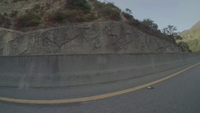
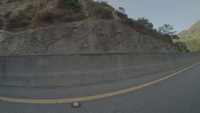
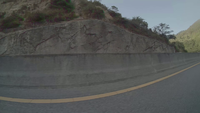
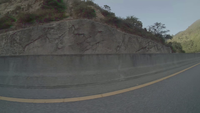
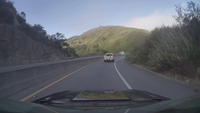
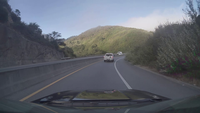
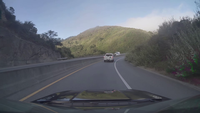
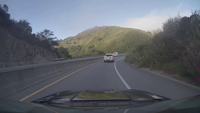
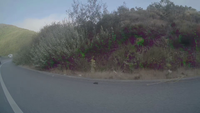
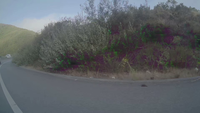
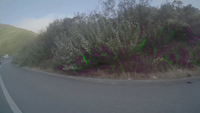
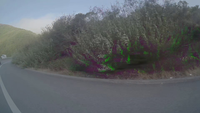
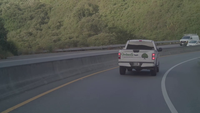
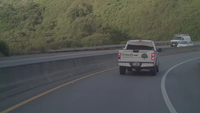
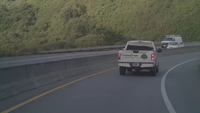
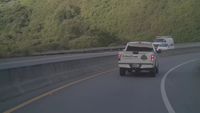

In [ ]:
mp.show_images(data["image_frames"].flatten(0, 1).permute(0, 2, 3, 1), columns=4, width=200)

(np.float64(-2.419581418577582),
 np.float64(50.98547049956396),
 np.float64(-2.85433606505394),
 np.float64(96.28812209963799))

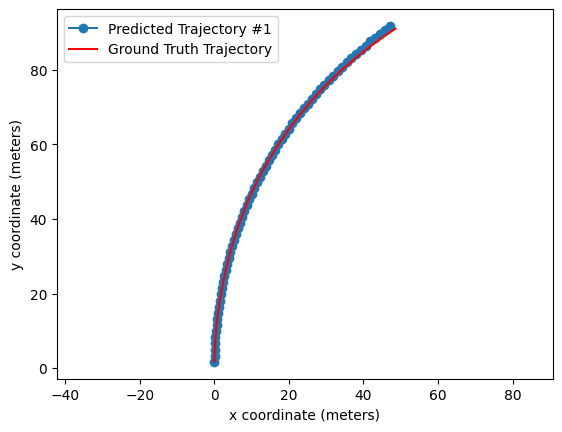

In [ ]:
import matplotlib.pyplot as plt


def rotate_90cc(xy):
    # Rotate (x, y) by 90 deg CCW -> (y, -x)
    return np.stack([-xy[1], xy[0]], axis=0)


for i in range(pred_xyz.shape[2]):
    pred_xy = pred_xyz.cpu()[0, 0, i, :, :2].T.numpy()
    pred_xy_rot = rotate_90cc(pred_xy)
    gt_xy = data["ego_future_xyz"].cpu()[0, 0, :, :2].T.numpy()
    gt_xy_rot = rotate_90cc(gt_xy)
    plt.plot(*pred_xy_rot, "o-", label=f"Predicted Trajectory #{i + 1}")
plt.ylabel("y coordinate (meters)")
plt.xlabel("x coordinate (meters)")
plt.plot(*gt_xy_rot, "r-", label="Ground Truth Trajectory")
plt.legend(loc="best")
plt.axis("equal")

In [ ]:
pred_xy = pred_xyz.cpu().numpy()[0, 0, :, :, :2].transpose(0, 2, 1)
diff = np.linalg.norm(pred_xy - gt_xy[None, ...], axis=1).mean(-1)
print("minADE:", diff.min(), "meters")

minADE: 0.41295505 meters
